# QualCheck – Training Pipeline (DREsS Edition)

**Camarines Sur Polytechnic Colleges – College of Computer Studies**

This notebook adapts the QualCheck pipeline to the **DREsS dataset** ([Yoo et al., 2025](https://aclanthology.org/2025.acl-long.659/)).

### DREsS → QualCheck conversion
| DREsS column | Role in QualCheck |
|---|---|
| `prompt` | `question` |
| `essay` | `response` |
| `score_content / score_organization / score_language` (1–5 float) | converted to `quality_label` (Fully Relevant / Partially Relevant / Irrelevant) |
| *(rubric text injected from DREsS paper)* | `rubric_descriptor` |
| *(one essay × 3 criteria = 3 rows)* | long-format dataset |

> **Expected CSV columns:** `id`, `prompt`, `essay`, `score_content`, `score_organization`, `score_language`  
> `source` and `total` columns are optional and ignored.

In [1]:
!pip install transformers torch scikit-learn pandas numpy nltk spacy scipy statsmodels matplotlib seaborn tqdm safetensors -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
print('✓ Packages ready')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✓ Packages ready


In [2]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, BertModel,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as tfidf_cos

from scipy.stats  import pearsonr, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import nltk
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

print('✓ Imports complete')


✓ Imports complete


## Configuration

In [ ]:
class Config:
    # ── DREsS file paths ──────────────────────────────────────────
    # Point each to the sub-dataset CSV you downloaded from the consent link.
    # Set to None to skip that sub-dataset.
    PATH_NEW  = "datasets/Dress/DREsS_New.tsv"     # 2,279 expert-scored EFL essays
    PATH_STD  = "datasets/Dress/DREsS_Std.tsv"     # 6,515 essays from existing datasets
    PATH_CASE_CONTENT = "datasets/Dress/DREsS_CASE_content.tsv"    
    PATH_CASE_ORG = "datasets/Dress/DREsS_CASE_organization.tsv"
    PATH_CASE_LANG = "datasets/Dress/DREsS_CASE_language.tsv"

    # ── Include/exclude the DREsS_CASE subsets ────────────────────
    # CASE subsets are single-criterion synthetic samples that, in testing,
    # showed weak/negative correlation for content & organization (see
    # holistic-vs-CASE diagnostic, Phase 5b). Set False to train/eval on
    # DREsS_New + DREsS_Std only (~8.8k rows instead of ~49k rows).
    # NOTE: with INCLUDE_CASE=False, train set shrinks a lot (~6.1k rows),
    # which raises overfitting risk again -- watch the loss curves closely.
    INCLUDE_CASE = True

    # ── Which criteria to include (set False to drop a rubric dimension) ──
    USE_CONTENT      = True
    USE_ORGANIZATION = True
    USE_LANGUAGE     = True

    # ── Score → label conversion (1–5 scale with 0.5 increments) ─
    #   score ≥ THRESH_HIGH          → Fully Relevant
    #   THRESH_LOW ≤ score < HIGH    → Partially Relevant
    #   score < THRESH_LOW           → Irrelevant
    THRESH_HIGH = 4.0
    THRESH_LOW  = 2.5

    # ── Labels ───────────────────────────────────────────────────
    LABEL2ID = {"Fully Relevant": 2, "Partially Relevant": 1, "Irrelevant": 0}
    ID2LABEL = {2: "Fully Relevant",  1: "Partially Relevant", 0: "Irrelevant"}
    NUM_LABELS = 3

    # ── BERT ─────────────────────────────────────────────────────
    BERT_MODEL = "bert-base-uncased"
    MAX_LEN    = 256      # reduce to 128 if GPU memory is tight

    # ── Training ─────────────────────────────────────────────────
    BATCH_SIZE   = 16
    LR           = 2e-5
    MAX_EPOCHS   = 5
    PATIENCE     = 2   # allow 2 epochs without val_loss improvement before stopping
                        # (was 3, then 1. patience=1 stopped at epoch 2 -- enough
                        #  for "language" to converge well (test r=0.67), but too
                        #  early for the harder "content"/"organization" criteria,
                        #  which need more epochs to develop useful representations.
                        #  patience=2 still catches genuine long-run divergence but
                        #  gives the model more room before cutting it off.)
    WARMUP_RATIO = 0.1
    DROPOUT      = 0.3

    # ── Split ────────────────────────────────────────────────────
    TRAIN_RATIO = 0.70
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15
    SEED        = 42

    # ── Threshold calibration ────────────────────────────────────
    THRESH_STEP = 0.01

    # ── Output ───────────────────────────────────────────────────
    OUTPUT_DIR  = "qualcheck_output"
    BEST_CKPT       = "qualcheck_output/best_model.safetensors"
    FINAL_MODEL     = "qualcheck_output/qualcheck_final.safetensors"
    FINAL_META      = "qualcheck_output/qualcheck_final_meta.json"  # non-tensor config (θ1, θ2, label map, …)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

random.seed(cfg.SEED); np.random.seed(cfg.SEED); torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f"Device : {cfg.DEVICE}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

## Phase 1 – DREsS Data Loading & Adaptation

### Step 1 – Rubric Definitions (from DREsS paper)

In [4]:
# Rubric descriptors taken verbatim from the DREsS dataset paper (Yoo et al., 2025)
DRESS_RUBRICS = {
    "content": {
        "criterion" : "Content",
        "descriptor": (
            "Paragraph is well-developed and relevant to the argument, "
            "supported with strong reasons and examples. The response "
            "demonstrates thorough understanding of the topic and provides "
            "detailed, accurate, and well-supported ideas that fully address "
            "the essay prompt."
        ),
        "score_col"  : "score_content"
    },
    "organization": {
        "criterion" : "Organization",
        "descriptor": (
            "The argument is very effectively structured and developed, making "
            "it easy for the reader to follow the ideas and understand how the "
            "writer is building the argument. Paragraphs use coherence devices "
            "effectively while focusing on a single main idea. The essay has a "
            "clear introduction, body, and conclusion with smooth transitions."
        ),
        "score_col"  : "score_organization"
    },
    "language": {
        "criterion" : "Language",
        "descriptor": (
            "The writing displays sophisticated control of a wide range of "
            "vocabulary and collocations. The essay follows grammar and usage "
            "rules throughout the paper. Spelling and punctuation are correct "
            "throughout the paper. Word choice is precise, varied, and "
            "contextually appropriate."
        ),
        "score_col"  : "score_language"
    }
}

enabled_criteria = [k for k, v in {
    "content":      cfg.USE_CONTENT,
    "organization": cfg.USE_ORGANIZATION,
    "language":     cfg.USE_LANGUAGE
}.items() if v]

print("Enabled criteria:", enabled_criteria)
for k in enabled_criteria:
    print(f"\n  [{k}]  {DRESS_RUBRICS[k]['descriptor'][:80]}…")


Enabled criteria: ['content', 'organization', 'language']

  [content]  Paragraph is well-developed and relevant to the argument, supported with strong …

  [organization]  The argument is very effectively structured and developed, making it easy for th…

  [language]  The writing displays sophisticated control of a wide range of vocabulary and col…


### Step 2 – Load & Validate DREsS CSVs

In [ ]:
def load_dress_tsv(path, source_tag):
    """Load one DREsS sub-dataset TSV and normalise column names."""
    if path is None or not os.path.exists(path):
        print(f"  [skip] {path} not found")
        return None

    df = pd.read_csv(path, sep='\t')
    print(f"  Loaded {path}  →  {df.shape}  columns: {df.columns.tolist()}")

    # Normalise to expected column names
    rename = {}
    for col in df.columns:
        cl = col.lower().strip().replace(" ", "_")
        # prompt / essay
        if cl in ("prompt",):           rename[col] = "prompt"
        elif cl in ("essay",):          rename[col] = "essay"
        # scores – handle both 'score_content' and nested 'score.content'
        elif "content"      in cl and "score" in cl: rename[col] = "score_content"
        elif "organization" in cl and "score" in cl: rename[col] = "score_organization"
        elif "organisation" in cl and "score" in cl: rename[col] = "score_organization"
        elif "language"     in cl and "score" in cl: rename[col] = "score_language"

    df = df.rename(columns=rename)
    df["_source"] = source_tag
    return df

print("Loading DREsS sub-datasets …")
sources_to_load = [(cfg.PATH_NEW,  "DREsS_New"),
                    (cfg.PATH_STD,  "DREsS_Std")]
if cfg.INCLUDE_CASE:
    sources_to_load += [(cfg.PATH_CASE_CONTENT, "DREsS_CASE_content"),
                         (cfg.PATH_CASE_ORG,     "DREsS_CASE_organization"),
                         (cfg.PATH_CASE_LANG,    "DREsS_CASE_language")]
else:
    print("  [INCLUDE_CASE=False] Skipping all DREsS_CASE_* subsets.")

frames = []
for path, tag in sources_to_load:
    f = load_dress_tsv(path, tag)
    if f is not None:
        frames.append(f)

assert frames, "No DREsS TSV files found – check PATH_NEW / PATH_STD / PATH_CASE_* in Config"
raw_df = pd.concat(frames, ignore_index=True)
print(f"\nCombined shape : {raw_df.shape}")
print(f"Columns        : {raw_df.columns.tolist()}")
print(f"Sub-datasets   : {raw_df['_source'].value_counts().to_dict()}")

### Step 3 – Convert Scores → 3-Class Labels & Melt to Long Format

Long-format rows : 66,546  (skipped 0 essays with blank fields)

Label distribution:
quality_label
Partially Relevant    29503
Fully Relevant        19399
Irrelevant            17644

Per-criterion:
quality_label  Fully Relevant  Irrelevant  Partially Relevant
criterion_key                                                
content                  5151        3987                7956
language                 1493        2093                5993
organization            12755       11564               15554


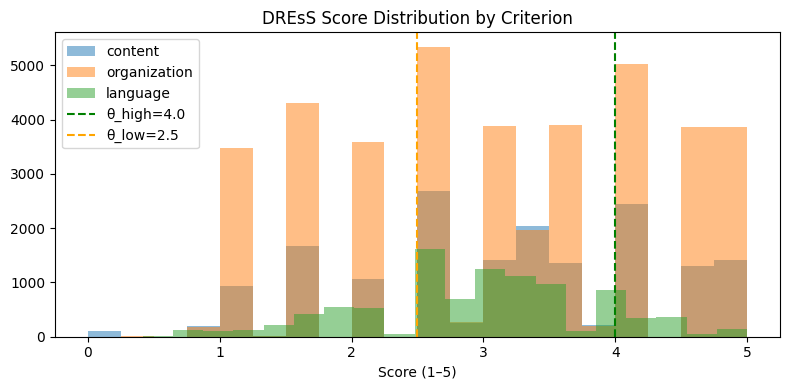

In [6]:
def score_to_label(score, high=cfg.THRESH_HIGH, low=cfg.THRESH_LOW):
    """Map a 1–5 float score to one of the three QualCheck relevance labels."""
    if pd.isna(score):
        return None
    if score >= high:
        return "Fully Relevant"
    elif score >= low:
        return "Partially Relevant"
    else:
        return "Irrelevant"

# Melt: one essay × N criteria  →  N rows ──────────────────────────
long_rows = []
skipped_essays = 0

for _, row in raw_df.iterrows():
    prompt = str(row.get("prompt", "")).strip()
    essay  = str(row.get("essay",  "")).strip()

    if not prompt or not essay:
        skipped_essays += 1
        continue

    for criterion_key in enabled_criteria:
        rubric_info = DRESS_RUBRICS[criterion_key]
        score_col   = criterion_key          # ← FIX: columns are 'content', 'organization', 'language'

        raw_score = row.get(score_col, None)
        label     = score_to_label(raw_score)

        if label is None:          # missing score for this criterion – skip row
            continue

        long_rows.append({
            "question"            : prompt,
            "evaluation_criterion": rubric_info["criterion"],
            "rubric_descriptor"   : rubric_info["descriptor"],
            "full_rubric"         : rubric_info["criterion"] + ". " + rubric_info["descriptor"],
            "response"            : essay,
            "raw_score"           : float(raw_score),
            "quality_label"       : label,
            "label_id"            : cfg.LABEL2ID[label],
            "output_type"         : "essay",
            "criterion_key"       : criterion_key,
            "_source"             : row["_source"]
        })

EXPECTED_COLS = [
    "question", "evaluation_criterion", "rubric_descriptor", "full_rubric",
    "response", "raw_score", "quality_label", "label_id",
    "output_type", "criterion_key", "_source"
]

df = pd.DataFrame(long_rows, columns=EXPECTED_COLS)

if df.empty:
    raise RuntimeError(
        f"No rows collected after melt. "
        f"skipped_essays={skipped_essays}, raw_df shape={raw_df.shape}. "
        f"Check that criterion keys {enabled_criteria} exist as columns in raw_df."
    )

print(f"Long-format rows : {len(df):,}  (skipped {skipped_essays} essays with blank fields)")
print(f"\nLabel distribution:")
print(df["quality_label"].value_counts().to_string())
print(f"\nPer-criterion:")
print(df.groupby(["criterion_key", "quality_label"]).size().unstack(fill_value=0).to_string())

# Score distribution overview
fig, ax = plt.subplots(figsize=(8, 4))
for k in enabled_criteria:
    subset = df[df["criterion_key"] == k]["raw_score"]
    ax.hist(subset, bins=20, alpha=0.5, label=k)
ax.axvline(cfg.THRESH_HIGH, color="green",  linestyle="--", label=f"θ_high={cfg.THRESH_HIGH}")
ax.axvline(cfg.THRESH_LOW,  color="orange", linestyle="--", label=f"θ_low={cfg.THRESH_LOW}")
ax.set_title("DREsS Score Distribution by Criterion")
ax.legend()
ax.set_xlabel("Score (1–5)")
plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/dress_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 4 – Text Preprocessing (NLTK + spaCy)

In [7]:
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))

    def clean_for_bert(self, text):
        return str(text).strip() if not pd.isna(text) else ""

    def deep_clean(self, text):
        """Lower → tokenise → drop stopwords → lemmatise (for TF-IDF baseline)."""
        if pd.isna(text):
            return ""
        tokens = nltk.word_tokenize(str(text).lower())
        return " ".join(self.lemmatizer.lemmatize(t)
                         for t in tokens if t.isalnum() and t not in self.stop_words)

prep = TextPreprocessor()

df["clean_question"]  = df["question"].apply(prep.clean_for_bert)
df["clean_rubric"]    = df["rubric_descriptor"].apply(prep.clean_for_bert)
df["clean_response"]  = df["response"].apply(prep.clean_for_bert)

df["tfidf_question"]  = df["question"].apply(prep.deep_clean)
df["tfidf_rubric"]    = df["full_rubric"].apply(prep.deep_clean)
df["tfidf_response"]  = df["response"].apply(prep.deep_clean)

print(f"✓ Preprocessing complete  –  {len(df):,} rows")
print("\nSample entry:")
print(df[["criterion_key","raw_score","quality_label","clean_response"]].iloc[0].to_string())


✓ Preprocessing complete  –  66,546 rows

Sample entry:
criterion_key                                               content
raw_score                                                       3.5
quality_label                                    Partially Relevant
clean_response    Many university classes requires the attendanc...


### Step 5 – Stratified 70 / 15 / 15 Split

In [8]:
# Stratify on (label_id, criterion_key, is_holistic) to keep class balance
# per criterion AND keep CASE vs. holistic (DREsS_New/Std) proportions
# consistent across train/val/test. Without the source flag, a split could
# by chance over- or under-represent CASE rows in one split vs another,
# which would make test-set numbers not comparable to val-set numbers.
df["is_holistic"] = (~df["_source"].str.startswith("DREsS_CASE")).astype(str)
df["strat_key"] = (df["label_id"].astype(str) + "_"
                    + df["criterion_key"] + "_"
                    + df["is_holistic"])

train_df, temp_df = train_test_split(df,
    test_size  = cfg.VAL_RATIO + cfg.TEST_RATIO,
    stratify   = df["strat_key"],
    random_state = cfg.SEED)

val_df, test_df = train_test_split(temp_df,
    test_size  = 0.5,
    stratify   = temp_df["strat_key"],
    random_state = cfg.SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

N = len(df)
print(f"Train : {len(train_df):>7,}  ({len(train_df)/N*100:.1f}%)")
print(f"Val   : {len(val_df):>7,}  ({len(val_df)/N*100:.1f}%)")
print(f"Test  : {len(test_df):>7,}  ({len(test_df)/N*100:.1f}%)")

print("\nTrain label distribution:")
print(train_df["quality_label"].value_counts().to_string())

# Sanity check: confirm CASE vs. holistic proportions match across splits
print("\nHolistic (DREsS_New/Std) vs CASE share per split, per criterion:")
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    pct = (d.groupby("criterion_key")["is_holistic"]
             .apply(lambda s: (s == "True").mean() * 100))
    print(f"  {name:5s}: " + ", ".join(f"{k}={v:.1f}%" for k, v in pct.items()))


Train :  46,582  (70.0%)
Val   :   9,982  (15.0%)
Test  :   9,982  (15.0%)

Train label distribution:
quality_label
Partially Relevant    20652
Fully Relevant        13579
Irrelevant            12351

Holistic (DREsS_New/Std) vs CASE share per split, per criterion:
  Train: content=51.4%, language=91.7%, organization=22.0%
  Val  : content=51.4%, language=91.7%, organization=22.0%
  Test : content=51.3%, language=91.8%, organization=22.0%


## Phase 2 – BERT Encoding & Fine-Tuning

In [9]:
class QualCheckDataset(Dataset):
    """
    P  →  [CLS] question [SEP] full_rubric [SEP]
    R  →  [CLS] response [SEP]
    """
    def __init__(self, dataframe, tokenizer, max_len):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):  return len(self.df)

    def _enc(self, a, b=None):
        return self.tokenizer(          # ← FIX: was self.tokenizer.encode_plus(
            a, b,
            add_special_tokens    = True,
            max_length            = self.max_len,
            padding               = "max_length",
            truncation            = True,
            return_attention_mask = True,
            return_tensors        = "pt"
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pr  = self._enc(row["clean_question"], row["full_rubric"])
        r   = self._enc(row["clean_response"])
        return {
            "pr_ids"  : pr["input_ids"].squeeze(0),
            "pr_mask" : pr["attention_mask"].squeeze(0),
            "r_ids"   : r["input_ids"].squeeze(0),
            "r_mask"  : r["attention_mask"].squeeze(0),
            "label"   : torch.tensor(row["label_id"], dtype=torch.long)
        }

In [10]:
class QualCheckModel(nn.Module):
    """Siamese BERT with a 4-feature classification head."""

    def __init__(self, bert_name, num_labels=3, dropout=0.3):
        super().__init__()
        self.bert      = BertModel.from_pretrained(bert_name)
        hidden         = self.bert.config.hidden_size   # 768
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 4, hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_labels)
        )

    def encode(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.dropout(out.last_hidden_state[:, 0, :])

    def forward(self, pr_ids, pr_mask, r_ids, r_mask):
        p       = self.encode(pr_ids,  pr_mask)
        r       = self.encode(r_ids,   r_mask)
        cos_sim = F.cosine_similarity(p, r, dim=1, eps=1e-8)
        feat    = torch.cat([p, r, torch.abs(p - r), p * r], dim=1)
        logits  = self.classifier(feat)
        return logits, cos_sim, p, r

    @torch.no_grad()
    def similarity(self, pr_ids, pr_mask, r_ids, r_mask):
        p = self.encode(pr_ids,  pr_mask)
        r = self.encode(r_ids,   r_mask)
        return F.cosine_similarity(p, r, dim=1, eps=1e-8)


In [ ]:
# ── Class weighting: counteract label imbalance without adding more data ──
# "Partially Relevant" dominates train_df (e.g. ~61% with INCLUDE_CASE=False),
# which biases the model toward over-predicting it and under-predicting the
# minority classes (see low recall on Irrelevant/Fully Relevant in the
# classification report). Inverse-frequency weights make mistakes on rarer
# classes cost more during training, without changing which rows are used.
_class_counts = train_df["label_id"].value_counts().sort_index()  # index 0,1,2
_class_weights = (1.0 / _class_counts).values
_class_weights = _class_weights / _class_weights.sum() * cfg.NUM_LABELS  # normalize, avg weight ~1
class_weights_t = torch.tensor(_class_weights, dtype=torch.float32).to(cfg.DEVICE)
print("Class counts (train):", _class_counts.to_dict())
print("Class weights (0=Irrelevant, 1=Partially, 2=Fully):", _class_weights.round(3).tolist())

criterion_loss = nn.CrossEntropyLoss(weight=class_weights_t)

def train_epoch(model, loader, opt, sch, device):
    model.train()
    total_loss = correct = n = 0
    for batch in tqdm(loader, desc="  Train", leave=False):
        pr_ids  = batch["pr_ids"].to(device);  pr_mask = batch["pr_mask"].to(device)
        r_ids   = batch["r_ids"].to(device);   r_mask  = batch["r_mask"].to(device)
        labels  = batch["label"].to(device)

        opt.zero_grad()
        logits, _, _, _ = model(pr_ids, pr_mask, r_ids, r_mask)
        loss = criterion_loss(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += labels.size(0)
    return total_loss / n, correct / n

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = correct = n = 0
    preds_all = []; labels_all = []
    for batch in tqdm(loader, desc="  Eval ", leave=False):
        pr_ids  = batch["pr_ids"].to(device);  pr_mask = batch["pr_mask"].to(device)
        r_ids   = batch["r_ids"].to(device);   r_mask  = batch["r_mask"].to(device)
        labels  = batch["label"].to(device)
        logits, _, _, _ = model(pr_ids, pr_mask, r_ids, r_mask)
        loss = criterion_loss(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item(); n += labels.size(0)
        preds_all.extend(preds.cpu().tolist());   labels_all.extend(labels.cpu().tolist())
    wf1 = f1_score(labels_all, preds_all, average="weighted", zero_division=0)
    return total_loss/n, correct/n, wf1

@torch.no_grad()
def extract_sims(model, dataframe, tokenizer, cfg):
    ds     = QualCheckDataset(dataframe, tokenizer, cfg.MAX_LEN)
    loader = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
    sims, lbls = [], []
    for batch in tqdm(loader, desc="  Embed", leave=False):
        cos = model.similarity(
            batch["pr_ids"].to(cfg.DEVICE), batch["pr_mask"].to(cfg.DEVICE),
            batch["r_ids"].to(cfg.DEVICE),  batch["r_mask"].to(cfg.DEVICE))
        sims.extend(cos.cpu().tolist())
        lbls.extend(batch["label"].tolist())
    return np.array(sims), np.array(lbls)


### Run Fine-Tuning

In [ ]:
from safetensors.torch import save_file as st_save_file, load_file as st_load_file

tokenizer = BertTokenizer.from_pretrained(cfg.BERT_MODEL)
model     = QualCheckModel(cfg.BERT_MODEL, cfg.NUM_LABELS, cfg.DROPOUT).to(cfg.DEVICE)

train_loader = DataLoader(QualCheckDataset(train_df, tokenizer, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(QualCheckDataset(val_df,   tokenizer, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

total_steps  = len(train_loader) * cfg.MAX_EPOCHS
optimiser    = AdamW(model.parameters(), lr=cfg.LR, eps=1e-8, weight_decay=0.01)
scheduler    = get_linear_schedule_with_warmup(
                   optimiser, int(total_steps * cfg.WARMUP_RATIO), total_steps)

history = {k: [] for k in ["tr_loss","tr_acc","val_loss","val_acc","val_wf1"]}
# Early stopping now keyed on val_loss, not val_wf1. val_wf1 plateaus and is
# too flat to detect overfitting onset (e.g. it kept "improving" 0.6569 ->
# 0.6608 between epochs 3-5 while val_loss rose 0.788 -> 1.003 over the same
# epochs) -- val_loss is the metric that actually reflects generalization.
best_val_loss = float("inf"); best_wf1 = 0.0; no_improve = 0

print(f"Training  |  device={cfg.DEVICE}  |  steps={total_steps}")
print("="*60)
for epoch in range(cfg.MAX_EPOCHS):
    tr_loss, tr_acc               = train_epoch(model, train_loader, optimiser, scheduler, cfg.DEVICE)
    val_loss, val_acc, val_wf1    = evaluate(model, val_loader, cfg.DEVICE)
    for k, v in zip(["tr_loss","tr_acc","val_loss","val_acc","val_wf1"],
                    [tr_loss, tr_acc, val_loss, val_acc, val_wf1]):
        history[k].append(v)

    tag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_wf1      = val_wf1
        # safetensors needs contiguous tensors and a flat str->Tensor dict (state_dict already is)
        st_save_file({k: v.contiguous() for k, v in model.state_dict().items()}, cfg.BEST_CKPT)
        tag = "  ← best (lowest val_loss)"
        no_improve = 0
    else:
        no_improve += 1

    print(f"Ep {epoch+1}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  ",
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_wf1={val_wf1:.4f}{tag}")

    if no_improve >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch+1} (no val_loss improvement for {cfg.PATIENCE} epoch(s))")
        break

print(f"\nBest Val Loss        : {best_val_loss:.4f}")
print(f"Best Val Weighted-F1 : {best_wf1:.4f}  (at the same checkpoint as best val_loss)")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history["tr_loss"])+1)
axes[0].plot(ep, history["tr_loss"], label="Train"); axes[0].plot(ep, history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(ep, history["tr_acc"],  label="Train"); axes[1].plot(ep, history["val_acc"],  label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(ep, history["val_wf1"], color="green", marker="o")
axes[2].axhline(0.80, color="red", linestyle="--", label="0.80"); axes[2].set_title("Val Weighted F1"); axes[2].legend()
for ax in axes: ax.set_xlabel("Epoch"); ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.suptitle("QualCheck Fine-Tuning – DREsS", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches="tight"); plt.show()


## Phase 3 – Cosine Similarity Scoring

In [ ]:
# safetensors loads straight to CPU tensors; .to(cfg.DEVICE) below moves the whole model
model.load_state_dict(st_load_file(cfg.BEST_CKPT))
model.to(cfg.DEVICE)
model.eval()

print("Extracting cosine similarities …")
val_sims,  val_true  = extract_sims(model, val_df,  tokenizer, cfg)
test_sims, test_true = extract_sims(model, test_df, tokenizer, cfg)

print(f"Val  sims  –  min={val_sims.min():.4f}  max={val_sims.max():.4f}  mean={val_sims.mean():.4f}")
print(f"Test sims  –  min={test_sims.min():.4f}  max={test_sims.max():.4f}  mean={test_sims.mean():.4f}")


In [ ]:
label_names = ["Irrelevant", "Partially Relevant", "Fully Relevant"]
colors      = ["#e74c3c", "#f39c12", "#27ae60"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lid in range(3):
    m = val_true == lid
    axes[0].hist(val_sims[m], bins=30, alpha=0.6, label=label_names[lid], color=colors[lid])
axes[0].set_title("Cosine Similarity by Class (Val)"); axes[0].set_xlabel("s"); axes[0].legend()

data_by_cls = [val_sims[val_true == i] for i in range(3)]
bp = axes[1].boxplot(data_by_cls, labels=label_names, patch_artist=True)
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title("Boxplot by Class (Val)"); axes[1].set_ylabel("Cosine Similarity  s")
plt.suptitle("Semantic Alignment Score Distribution – DREsS", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/similarity_distribution.png", dpi=150, bbox_inches="tight"); plt.show()


## Phase 4 – Threshold Calibration (Grid Search)

In [ ]:
def classify(sims, t1, t2):
    preds = np.zeros(len(sims), dtype=int)
    preds[sims >= t1]                    = 2
    preds[(sims >= t2) & (sims < t1)]   = 1
    return preds

def grid_search(sims, true_labels, step=0.01):
    cands = np.arange(float(sims.min()), float(sims.max()), step)
    best  = dict(t1=0.8, t2=0.5, score=0.0)
    for t1 in cands:
        for t2 in cands:
            if t2 >= t1: continue
            p   = classify(sims, t1, t2)
            acc = accuracy_score(true_labels, p)
            wf1 = f1_score(true_labels, p, average="weighted", zero_division=0)
            s   = (acc + wf1) / 2
            if s > best["score"]:
                best.update(t1=t1, t2=t2, score=s)
    return best

print("Running grid search on validation set …")
res   = grid_search(val_sims, val_true, cfg.THRESH_STEP)
θ1    = res["t1"]; θ2 = res["t2"]

print(f"\n{'='*50}")
print(f" θ₁ (Fully Relevant   boundary) : {θ1:.4f}")
print(f" θ₂ (Irrelevant       boundary) : {θ2:.4f}")
print(f" Combined score (acc+wf1)/2     : {res['score']:.4f}")
print(f"\n s ≥ {θ1:.4f}                → Fully Relevant")
print(f" {θ2:.4f} ≤ s < {θ1:.4f}   → Partially Relevant")
print(f" s <  {θ2:.4f}               → Irrelevant")


## Phase 5 – System Evaluation

In [ ]:
qc_preds = classify(test_sims, θ1, θ2)

acc  = accuracy_score(test_true, qc_preds)
prec = precision_score(test_true, qc_preds, average="weighted", zero_division=0)
rec  = recall_score(test_true, qc_preds, average="weighted", zero_division=0)
f1m  = f1_score(test_true, qc_preds, average="macro",    zero_division=0)
f1w  = f1_score(test_true, qc_preds, average="weighted", zero_division=0)

print("QualCheck (DREsS) – Test Set"); print("-"*40)
print(f"Accuracy       : {acc:.4f}")
print(f"Precision (W)  : {prec:.4f}")
print(f"Recall    (W)  : {rec:.4f}")
print(f"F1 (macro)     : {f1m:.4f}")
print(f"Weighted F1    : {f1w:.4f}  ({'✓ PASSED' if f1w>=0.80 else '✗ FAILED'}, threshold ≥ 0.80)")
print("\nClassification Report:")
print(classification_report(test_true, qc_preds, target_names=label_names))


In [ ]:
cm = confusion_matrix(test_true, qc_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Irrelevant","Partially\nRelevant","Fully\nRelevant"],
            yticklabels=["Irrelevant","Partially\nRelevant","Fully\nRelevant"],
            linewidths=0.5)
ax.set_title("QualCheck – Confusion Matrix (DREsS Test Set)", fontweight="bold")
ax.set_ylabel("True"); ax.set_xlabel("Predicted"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.show()


### Semantic Alignment Quality (MAE, RMSE, Pearson r)

In [ ]:
norm_true = test_true / (cfg.NUM_LABELS - 1)
mae   = np.mean(np.abs(test_sims - norm_true))
rmse  = np.sqrt(np.mean((test_sims - norm_true)**2))
r, pr = pearsonr(test_sims, norm_true)
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"Pearson r  : {r:.4f}  (p={pr:.4f})  {'✓ r≥0.70' if r>=0.70 else '✗ r<0.70'}")


## Phase 5b – Diagnostic: Holistic vs. CASE-Subset Performance

The full DREsS test set mixes holistic, expert/curated essays (DREsS_New +
DREsS_Std) with the much larger, single-criterion-focused DREsS_CASE subset.
Per the dataset's own published composition, CASE makes up ~49% of Content
rows, ~78% of Organization rows, and only ~8% of Language rows — so the
aggregate test metrics above are not equally informative for every criterion.

This cell re-evaluates the **same trained model, same thresholds (θ1/θ2),
same test split** — just sliced by source — to see how much of the
Content/Organization gap is attributable to CASE-dominance rather than the
model itself. No retraining, no architecture or method changes.

In [ ]:
# ── Diagnostic: full test set vs. holistic-only (non-CASE) subset ───
is_holistic_mask = (test_df["is_holistic"].values == "True")

def eval_slice(name, mask):
    if mask.sum() < 2:
        print(f"  {name:28s}: too few rows ({mask.sum()}), skipping")
        return None
    sims_s, true_s = test_sims[mask], test_true[mask]
    preds_s = classify(sims_s, θ1, θ2)
    acc_s   = accuracy_score(true_s, preds_s)
    wf1_s   = f1_score(true_s, preds_s, average="weighted", zero_division=0)
    norm_s  = true_s / (cfg.NUM_LABELS - 1)
    mae_s   = np.mean(np.abs(sims_s - norm_s))
    r_s, _  = (pearsonr(sims_s, norm_s) if mask.sum() > 1 else (float("nan"), None))
    print(f"  {name:28s}: n={mask.sum():>6,}  Acc={acc_s:.4f}  WF1={wf1_s:.4f}  "
          f"r={r_s:.4f}  MAE={mae_s:.4f}")
    return dict(name=name, n=int(mask.sum()), acc=acc_s, wf1=wf1_s, r=r_s, mae=mae_s)

print("="*78)
print("Overall (full test set, all sources mixed) — same as Phase 5 above:")
eval_slice("Full test set", np.ones(len(test_true), dtype=bool))

print("\nHolistic-only (DREsS_New + DREsS_Std) vs. CASE-only, per criterion:")
print("-"*78)
rows = []
for crit in enabled_criteria:
    crit_mask = (test_df["criterion_key"].values == crit)
    print(f"[{crit}]")
    r1 = eval_slice("  Holistic (New+Std)", crit_mask & is_holistic_mask)
    r2 = eval_slice("  CASE-only",          crit_mask & ~is_holistic_mask)
    for r_ in (r1, r2):
        if r_ is not None:
            r_["criterion"] = crit
            rows.append(r_)

diag_df = pd.DataFrame(rows)
diag_df.to_csv(f"{cfg.OUTPUT_DIR}/holistic_vs_case_diagnostic.csv", index=False)
print("\nSaved: holistic_vs_case_diagnostic.csv")
print(diag_df.to_string(index=False))

# Quick bar chart: WF1 by criterion, holistic vs CASE
if len(diag_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot = diag_df.pivot(index="criterion", columns="name", values="wf1")
    pivot.plot(kind="bar", ax=ax, color=["#27ae60", "#e74c3c"])
    ax.set_title("Weighted F1: Holistic vs. CASE-Subset Test Rows", fontweight="bold")
    ax.set_ylabel("Weighted F1"); ax.set_xlabel(""); ax.legend(title="")
    plt.xticks(rotation=0); plt.tight_layout()
    plt.savefig(f"{cfg.OUTPUT_DIR}/holistic_vs_case_wf1.png", dpi=150, bbox_inches="tight")
    plt.show()


### Per-Criterion Breakdown

In [ ]:
print("Per-Criterion Performance (Test Set)")
print(f"{'Criterion':<16} {'Acc':>6} {'WF1':>6} {'Pearson r':>10} {'n':>6}")
print("-" * 50)

test_df2 = test_df.reset_index(drop=True)
for k in enabled_criteria:
    mask = test_df2["criterion_key"].values == k
    if mask.sum() == 0: continue
    ts   = test_sims[mask]; tl = test_true[mask]; tp = qc_preds[mask]
    nt   = norm_true[mask]
    a    = accuracy_score(tl, tp)
    w    = f1_score(tl, tp, average="weighted", zero_division=0)
    rc,_ = pearsonr(ts, nt) if len(ts) > 2 else (float("nan"), None)
    print(f"{k:<16} {a:>6.4f} {w:>6.4f} {rc:>10.4f} {mask.sum():>6}")


### Baseline Comparisons

In [ ]:
# ── Baseline 1 : TF-IDF ──────────────────────────────────────────
print("--- Baseline 1: TF-IDF Cosine Similarity ---")
tfidf_all = (list(train_df["tfidf_question"] + " " + train_df["tfidf_rubric"]) +
             list(train_df["tfidf_response"]))
tv = TfidfVectorizer(max_features=10_000, ngram_range=(1,2)); tv.fit(tfidf_all)

def tfidf_sims_df(df_sp):
    pr = tv.transform(df_sp["tfidf_question"] + " " + df_sp["tfidf_rubric"])
    r  = tv.transform(df_sp["tfidf_response"])
    return np.array([tfidf_cos(pr[i], r[i])[0,0] for i in range(len(df_sp))])

bl1_vs = tfidf_sims_df(val_df);  bl1_ts = tfidf_sims_df(test_df)
bl1r   = grid_search(bl1_vs, val_true, 0.01)
bl1_p  = classify(bl1_ts, bl1r["t1"], bl1r["t2"])
bl1_acc = accuracy_score(test_true, bl1_p)
bl1_wf1 = f1_score(test_true, bl1_p, average="weighted", zero_division=0)
bl1_r,_ = pearsonr(bl1_ts, norm_true)
bl1_mae = np.mean(np.abs(bl1_ts - norm_true))
print(f"  Acc={bl1_acc:.4f}  WF1={bl1_wf1:.4f}  r={bl1_r:.4f}  MAE={bl1_mae:.4f}")

# ── Baseline 2 : BERT no rubric ───────────────────────────────────
print("--- Baseline 2: BERT without rubric ---")
@torch.no_grad()
def bert_no_rubric(model, df_sp, tokenizer, cfg):
    sims = []
    model.eval()
    for _, row in tqdm(df_sp.iterrows(), total=len(df_sp), desc="  BL2", leave=False):
        q = tokenizer(row["clean_question"], add_special_tokens=True,
            max_length=cfg.MAX_LEN, padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")
        r = tokenizer(row["clean_response"],  add_special_tokens=True,
            max_length=cfg.MAX_LEN, padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt")
        c = model.similarity(q["input_ids"].to(cfg.DEVICE), q["attention_mask"].to(cfg.DEVICE),
                             r["input_ids"].to(cfg.DEVICE), r["attention_mask"].to(cfg.DEVICE))
        sims.append(c.item())
    return np.array(sims)

bl2_vs = bert_no_rubric(model, val_df,  tokenizer, cfg)
bl2_ts = bert_no_rubric(model, test_df, tokenizer, cfg)
bl2r   = grid_search(bl2_vs, val_true, 0.01)
bl2_p  = classify(bl2_ts, bl2r["t1"], bl2r["t2"])
bl2_acc = accuracy_score(test_true, bl2_p)
bl2_wf1 = f1_score(test_true, bl2_p, average="weighted", zero_division=0)
bl2_r,_ = pearsonr(bl2_ts, norm_true)
bl2_mae = np.mean(np.abs(bl2_ts - norm_true))
print(f"  Acc={bl2_acc:.4f}  WF1={bl2_wf1:.4f}  r={bl2_r:.4f}  MAE={bl2_mae:.4f}")


In [ ]:
summary = pd.DataFrame({
    "System"      : ["BL1 – TF-IDF", "BL2 – BERT (no rubric)", "QualCheck (Ours)"],
    "Accuracy"    : [bl1_acc, bl2_acc, acc],
    "Weighted F1" : [bl1_wf1, bl2_wf1, f1w],
    "Pearson r"   : [bl1_r,   bl2_r,   r],
    "MAE"         : [bl1_mae, bl2_mae, mae],
    "ΔWF1 vs BL1" : [0.0, round(bl2_wf1-bl1_wf1,4), round(f1w-bl1_wf1,4)],
    "ΔMAE vs BL1" : [0.0, round(bl2_mae-bl1_mae,4), round(mae-bl1_mae,4)],
})
summary.to_csv(f"{cfg.OUTPUT_DIR}/results_summary.csv", index=False)
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sys_l  = ["BL1\n(TF-IDF)", "BL2\n(BERT)", "QualCheck"]
colors2 = ["#bdc3c7", "#f0b27a", "#82e0aa"]
for ax, metric in zip(axes, ["Weighted F1", "Accuracy"]):
    vals = summary[metric].tolist()
    bars = ax.bar(sys_l, vals, color=colors2, edgecolor="black", width=0.5)
    ax.set_ylim(0, 1.1); ax.axhline(0.80, color="red", linestyle="--", lw=1.2, label="0.80")
    ax.set_title(f"{metric} Comparison", fontweight="bold"); ax.legend()
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.4f}",
                ha="center", fontweight="bold", fontsize=9)
plt.suptitle("System Comparison – DREsS Test Set", fontweight="bold"); plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/system_comparison.png", dpi=150, bbox_inches="tight"); plt.show()


### Statistical Tests

In [ ]:
print("1. Pearson r (QualCheck)")
print(f"   r={r:.4f}  p={pr:.4f}  {'✓ r≥0.70' if r>=0.70 else '✗ r<0.70'}\n")

print("2. One-Way ANOVA – cross-criterion consistency")
groups = [test_sims[test_df.reset_index(drop=True)["criterion_key"].values == k]
          for k in enabled_criteria]
groups = [g for g in groups if len(g) > 1]
if len(groups) >= 2:
    F, pv = f_oneway(*groups)
    print(f"   F={F:.4f}  p={pv:.4f}")
    if pv > 0.05:
        print("   Non-significant (p>0.05): consistent across criteria ✓")
    else:
        print("   Significant (p≤0.05): Tukey HSD:")
        all_s = np.concatenate(groups)
        all_g = np.concatenate([[k]*len(g) for k, g in zip(enabled_criteria, groups)])
        print(pairwise_tukeyhsd(all_s, all_g, alpha=0.05))

print("\n3. Descriptive Statistics (cosine similarity by class)")
print(f"{'Class':<22} {'Mean':>6} {'Median':>8} {'Std':>6} {'IQR':>6}")
print("-"*50)
for lid, lname in cfg.ID2LABEL.items():
    m = test_true == lid
    if m.any():
        s   = test_sims[m]
        iqr = np.percentile(s,75) - np.percentile(s,25)
        print(f"{lname:<22} {s.mean():>6.4f} {np.median(s):>8.4f} {s.std():>6.4f} {iqr:>6.4f}")


## Save Final Model & Predictions

In [ ]:
import json as _json  # local import to avoid clashing with any 'json' var used elsewhere

# Weights go in .safetensors (tensors only). Everything else (thresholds,
# label map, etc.) is plain Python/JSON, not tensor data, so it can't live
# inside a safetensors file — it goes in a small JSON sidecar next to it.
st_save_file({k: v.contiguous() for k, v in model.state_dict().items()}, cfg.FINAL_MODEL)

final_meta = {
    "theta1"      : float(θ1),
    "theta2"      : float(θ2),
    "bert_model"  : cfg.BERT_MODEL,
    "max_len"     : cfg.MAX_LEN,
    "label_map"   : cfg.LABEL2ID,
    "thresh_high" : cfg.THRESH_HIGH,
    "thresh_low"  : cfg.THRESH_LOW,
    "criteria"    : enabled_criteria,
}
with open(cfg.FINAL_META, "w") as f:
    _json.dump(final_meta, f, indent=2)

print(f"Saved weights   -> {cfg.FINAL_MODEL}")
print(f"Saved metadata  -> {cfg.FINAL_META}")

out = test_df[["question","evaluation_criterion","rubric_descriptor",
               "response","raw_score","quality_label","criterion_key"]].copy()
out["cosine_similarity"] = test_sims
out["predicted_label"]   = [cfg.ID2LABEL[p] for p in qc_preds]
out["correct"]           = (test_true == qc_preds)
out.to_csv(f"{cfg.OUTPUT_DIR}/test_predictions.csv", index=False)

print("="*60)
print(" QUALCHECK – DREsS FINAL RESULTS")
print("="*60)
print(f" θ₁ = {θ1:.4f}   θ₂ = {θ2:.4f}")
print(f" Accuracy    : {acc:.4f}")
print(f" Weighted F1 : {f1w:.4f}  ({'✓' if f1w>=0.80 else '✗'} ≥ 0.80)")
print(f" Pearson r   : {r:.4f}  ({'✓' if r>=0.70 else '✗'} ≥ 0.70)")
print(f" MAE         : {mae:.4f}  |  RMSE : {rmse:.4f}")
print(f" ΔWF1 vs BL1 : {f1w-bl1_wf1:+.4f}  |  ΔWF1 vs BL2 : {f1w-bl2_wf1:+.4f}")
print("="*60)
print("✓ QualCheck – DREsS pipeline complete!")
